In [25]:
# Practice Problem
# Do NER on "Apple is looking at buying UK startup for $1 billion. Elon Musk founded SpaceX"
# Do tokenization
# Remove Stop words
# Do POS tagging
# Do Lemmatization
# Do NER on lemmatized list

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

!pip install svgling

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [26]:
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords

def get_wordnet_pos(tag):
  if tag.startswith('J'):
    return wordnet.ADJ
  elif tag.startswith('V'):
    return wordnet.VERB
  elif tag.startswith('N'):
    return wordnet.NOUN
  elif tag.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN

def remove_stop_words(tokens):
  stop_words = list(set(map(str.lower, stopwords.words('english'))))

  filtered_words = [word for word in tokens if word.lower() not in stop_words]
  return filtered_words

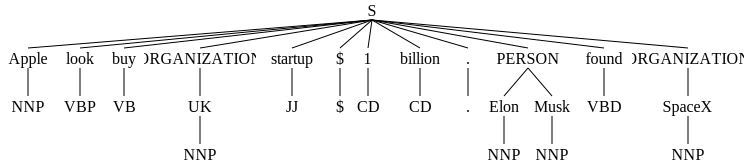

In [27]:
text = "Apple is looking at buying UK startup for $1 billion. Elon Musk founded SpaceX"
# text = "In 2026, Sundar Pichai announced that Google would expand its offices in Newark."
tokens = word_tokenize(text)

cleaned_tokens = remove_stop_words(tokens)
pos_tags = pos_tag(cleaned_tokens)

# Do lemmatization
lemmatizer = WordNetLemmatizer()
lemma_list = list()
for word, tag in pos_tags:
  lemma_list.append(lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag)))


# To do NER on lemmatized list we need to do the pos_tagging first. Because ne_chunk() needs input as array of tuples which contain word and corresponding POS tag
lemmatized_pos_tags = pos_tag(lemma_list)
ner_tree = ne_chunk(lemmatized_pos_tags)
ner_tree
